# System Setup & GPU Verification

In this section, we verify the system environment and ensure that TensorFlow is correctly installed and operational.
First, we check the available physical devices (CPU and/or GPU) recognized by TensorFlow.
Then, we perform a simple matrix multiplication to confirm that computations execute successfully.
This step helps ensure that the GPU (if available) can be leveraged for accelerated training during subsequent model development.


This section is especially important when running TensorFlow on **macOS**, as GPU support is not always straightforward.  
- macOS machines (especially those with Apple Silicon like **M1/M2 chips**) use **Metal**, and TensorFlow support requires the **tensorflow-metal** plugin.
- Verifying device availability helps confirm that TensorFlow has access to the **GPU via Metal**, or whether it's running on **CPU only**.
- Running a test operation like matrix multiplication ensures that the TensorFlow installation is functional and that device acceleration (if present) is utilized.

Without this verification, users may mistakenly assume the GPU is being used when, in reality, TensorFlow could be defaulting to the CPU — leading to **slower training times**.


In [ ]:
import tensorflow as tf
print(tf.__version__)

In [ ]:
import tensorflow as tf

# Check available devices
print("Available devices:", tf.config.list_physical_devices())

# Create a simple TensorFlow computation to see if the GPU is used
a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
b = tf.constant([[1.0, 1.0], [0.0, 1.0]])
c = tf.matmul(a, b)

print("Result of matrix multiplication:\n", c)

In [ ]:
import tensorflow as tf

print("Available devices:", tf.config.list_physical_devices())

Got it! You're asking to **keep your original chapter structure and names**, but **correct and align the explanations** to reflect what was actually done in the code you provided — especially around preprocessing, model architecture, training, and MLflow tracking.

Here's the **corrected version**, preserving your original sections but with updated, accurate explanations:

---

# Project Task: CIFAR-10 Image Classification Using ResNet50

**Objective**

The goal of this project is to classify images from the CIFAR-10 dataset using a pretrained ResNet50 model and fine-tune it for improved accuracy. CIFAR-10 contains 10 distinct image classes such as airplanes, cats, and trucks, each with 6,000 32×32 RGB images.

This project uses a subset of the dataset (10,000 images total) for faster experimentation. The workflow involves transfer learning with ResNet50, advanced preprocessing, custom head construction, and performance logging using MLflow.

- Official CIFAR-10 Website:  
  🔗 https://www.cs.toronto.edu/~kriz/cifar.html  
- Original Research Paper:  
  📄 Krizhevsky, A. (2009). *Learning Multiple Layers of Features from Tiny Images*  
  🔗 https://www.cs.toronto.edu/~kriz/learning-features-2009-TR.pdf

---

##  Key Steps of the Project

---

**1. Import Required Libraries**

We import essential Python libraries such as TensorFlow/Keras for model development, OpenCV (`cv2`) for image manipulation, NumPy for data handling, and MLflow for experiment tracking.

---

**2. Load and Limit the Dataset**

We use TensorFlow’s built-in CIFAR-10 loader to import the dataset and then **limit the training and test sets** to **10,000 samples total** to reduce training time while preserving class balance.

---

**3. Preprocess the Data**

Preprocessing includes:

Applying high-quality bilinear interpolation using OpenCV (cv2.INTER_LINEAR) to standardize the input format.
Note: The original CIFAR-10 images are already sized at 32×32; this step is used for interpolation consistency, not resizing.
Convert images from RGB to BGR
Zero-center each channel using the mean pixel values from ImageNet
No scaling by 255 — as required by ResNet models in Kerashis prepares the input to match what ResNet50 expects during inference and fine-tuning.

---

**4. Load Pretrained ResNet50 Model**

We load **ResNet50** with `include_top=False` and pretrained **ImageNet weights**. This removes the original classifier and retains the convolutional feature extractor. Input shape is set to `(32, 32, 3)` to match CIFAR-10 dimensions.

Initially, all layers in the base model are **frozen** to preserve pre-trained weights.

---

**5. Build and Customize the Model Head**

We construct a custom classification head on top of ResNet50 consisting of:

- `GlobalAveragePooling2D` to flatten spatial features  
- Dense layers: `256 → 128 + BatchNorm → 64 + BatchNorm → Dropout(0.6)`
- Final layer: `Dense(10)` with softmax activation for 10-class classification
- **L2 Regularization** is added to Dense layers to combat overfitting

---

**6. Compile the Model**

We compile the model with:

- **Loss**: `SparseCategoricalCrossentropy` (since labels are integer-encoded)
- **Optimizer**: Adam
- **Metric**: Accuracy

---

**7. Train the Custom Model Head**

We train only the **custom top layers** while keeping the ResNet50 base frozen. Training is run for **10 epochs** with validation monitoring. Metrics (accuracy/loss) are logged at each epoch using **MLflow**.

---

**8. Unfreeze and Fine-Tune the Base Model**

The model is trained in two phases:

- **Phase 1:** Unfreeze only the **last 100 layers** of ResNet50 and train for 5 epochs  
- **Phase 2:** Unfreeze the **entire base model**, but **keep BatchNormalization layers frozen** to prevent destabilization. Train for an additional 15 epochs with a **reduced learning rate**.

**Callbacks used:**
- `EarlyStopping` to stop when validation loss plateaus
- `ReduceLROnPlateau` to dynamically lower LR on stagnation
- `ModelCheckpoint` to save the best model based on validation accuracy

---

**9. Evaluate Model Performance**

We evaluate the final model on the test set, logging final accuracy and loss. All training curves and results are tracked in **MLflow**, and the best model is saved locally for reuse.

---

**10. Optimize and Experiment Further**

The project allows further exploration, including:

- Testing with different learning rate schedules
- Tuning L2 regularization values
- Evaluating performance per class using classification reports and confusion matrices
- Experimenting with other pretrained architectures or head structures

# **1. Import Required Libraries**

In [ ]:
!pip install --force-reinstall --ignore-installed blinker

In [ ]:
pip install mlflow


In [ ]:
pip install tensorflow

In [ ]:
!pip install opencv-python

In [1]:
import tensorflow as tf
import keras
import cv2
from keras import layers, models
from keras.applications import ResNet50
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import cifar10
import mlflow
import mlflow.tensorflow
from tensorflow.keras.callbacks import EarlyStopping



# **2. Load and Limit the Dataset**

In [2]:
#Load CIFAR-10 dataset
(train_images, train_labels),(test_images,test_labels) = cifar10.load_data()

In [3]:
#According to the task we need to limit our data till 10000
#n=10000
#train_images = train_images[:n]
#train_labels = train_labels[:n]

#test_images = test_images[:n]
#test_labels = test_labels[:n]


# **3. Preprocess the Data**

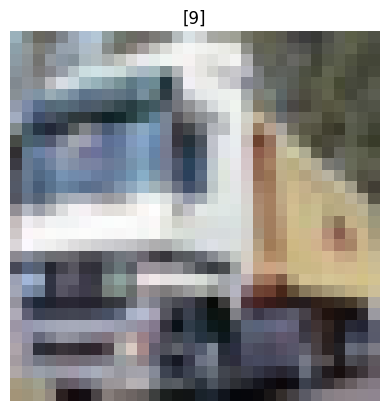

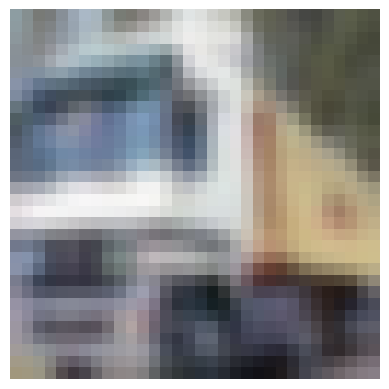

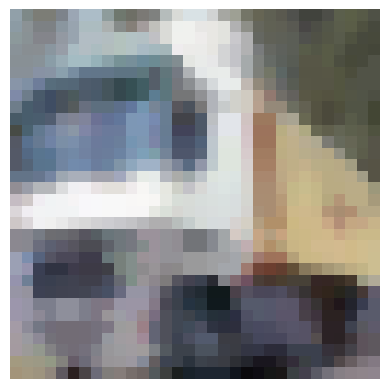

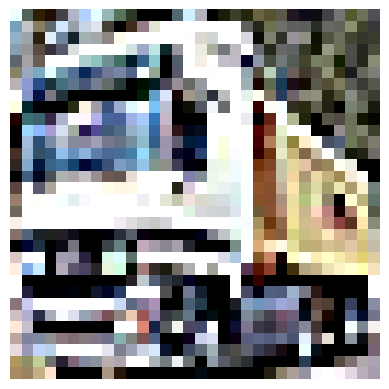

In [4]:
# Display the initial image
plt.imshow(train_images[1])
plt.title(train_labels[1])
plt.axis('off')
plt.show()

#Apply GAUSSIAN Filter to enhance edges and reduce noise
plt.imshow(cv2.GaussianBlur(train_images[1], (3, 3), 0))
plt.axis('off')
plt.show()

# Apply Median Filter to enhance edges and reduce noise
plt.imshow(cv2.medianBlur(train_images[1], 3))
plt.axis('off')
plt.show()


# Apply Sharpening Filter to enhance clarity
kernel = np.array([[0, -1, 0],
                  [-1, 5, -1],
                  [0, -1, 0]])
plt.imshow(cv2.filter2D(src=train_images[1], ddepth=-1, kernel=kernel))
plt.axis('off')
plt.show()

Observations:

For noise reduction: The Gaussian blur and median filter work well, with the median filter being better for impulse noise (salt-and-pepper).

For feature enhancement: The sharpening filter improves clarity but may amplify noise.

For further improvement: Combining Gaussian blur + Sharpening may produce a cleaner, yet sharp image.

In [5]:
#Display unique labels
np.unique(train_labels)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [6]:
#Count the number of unique labels
count_labels = len(np.unique(train_labels))

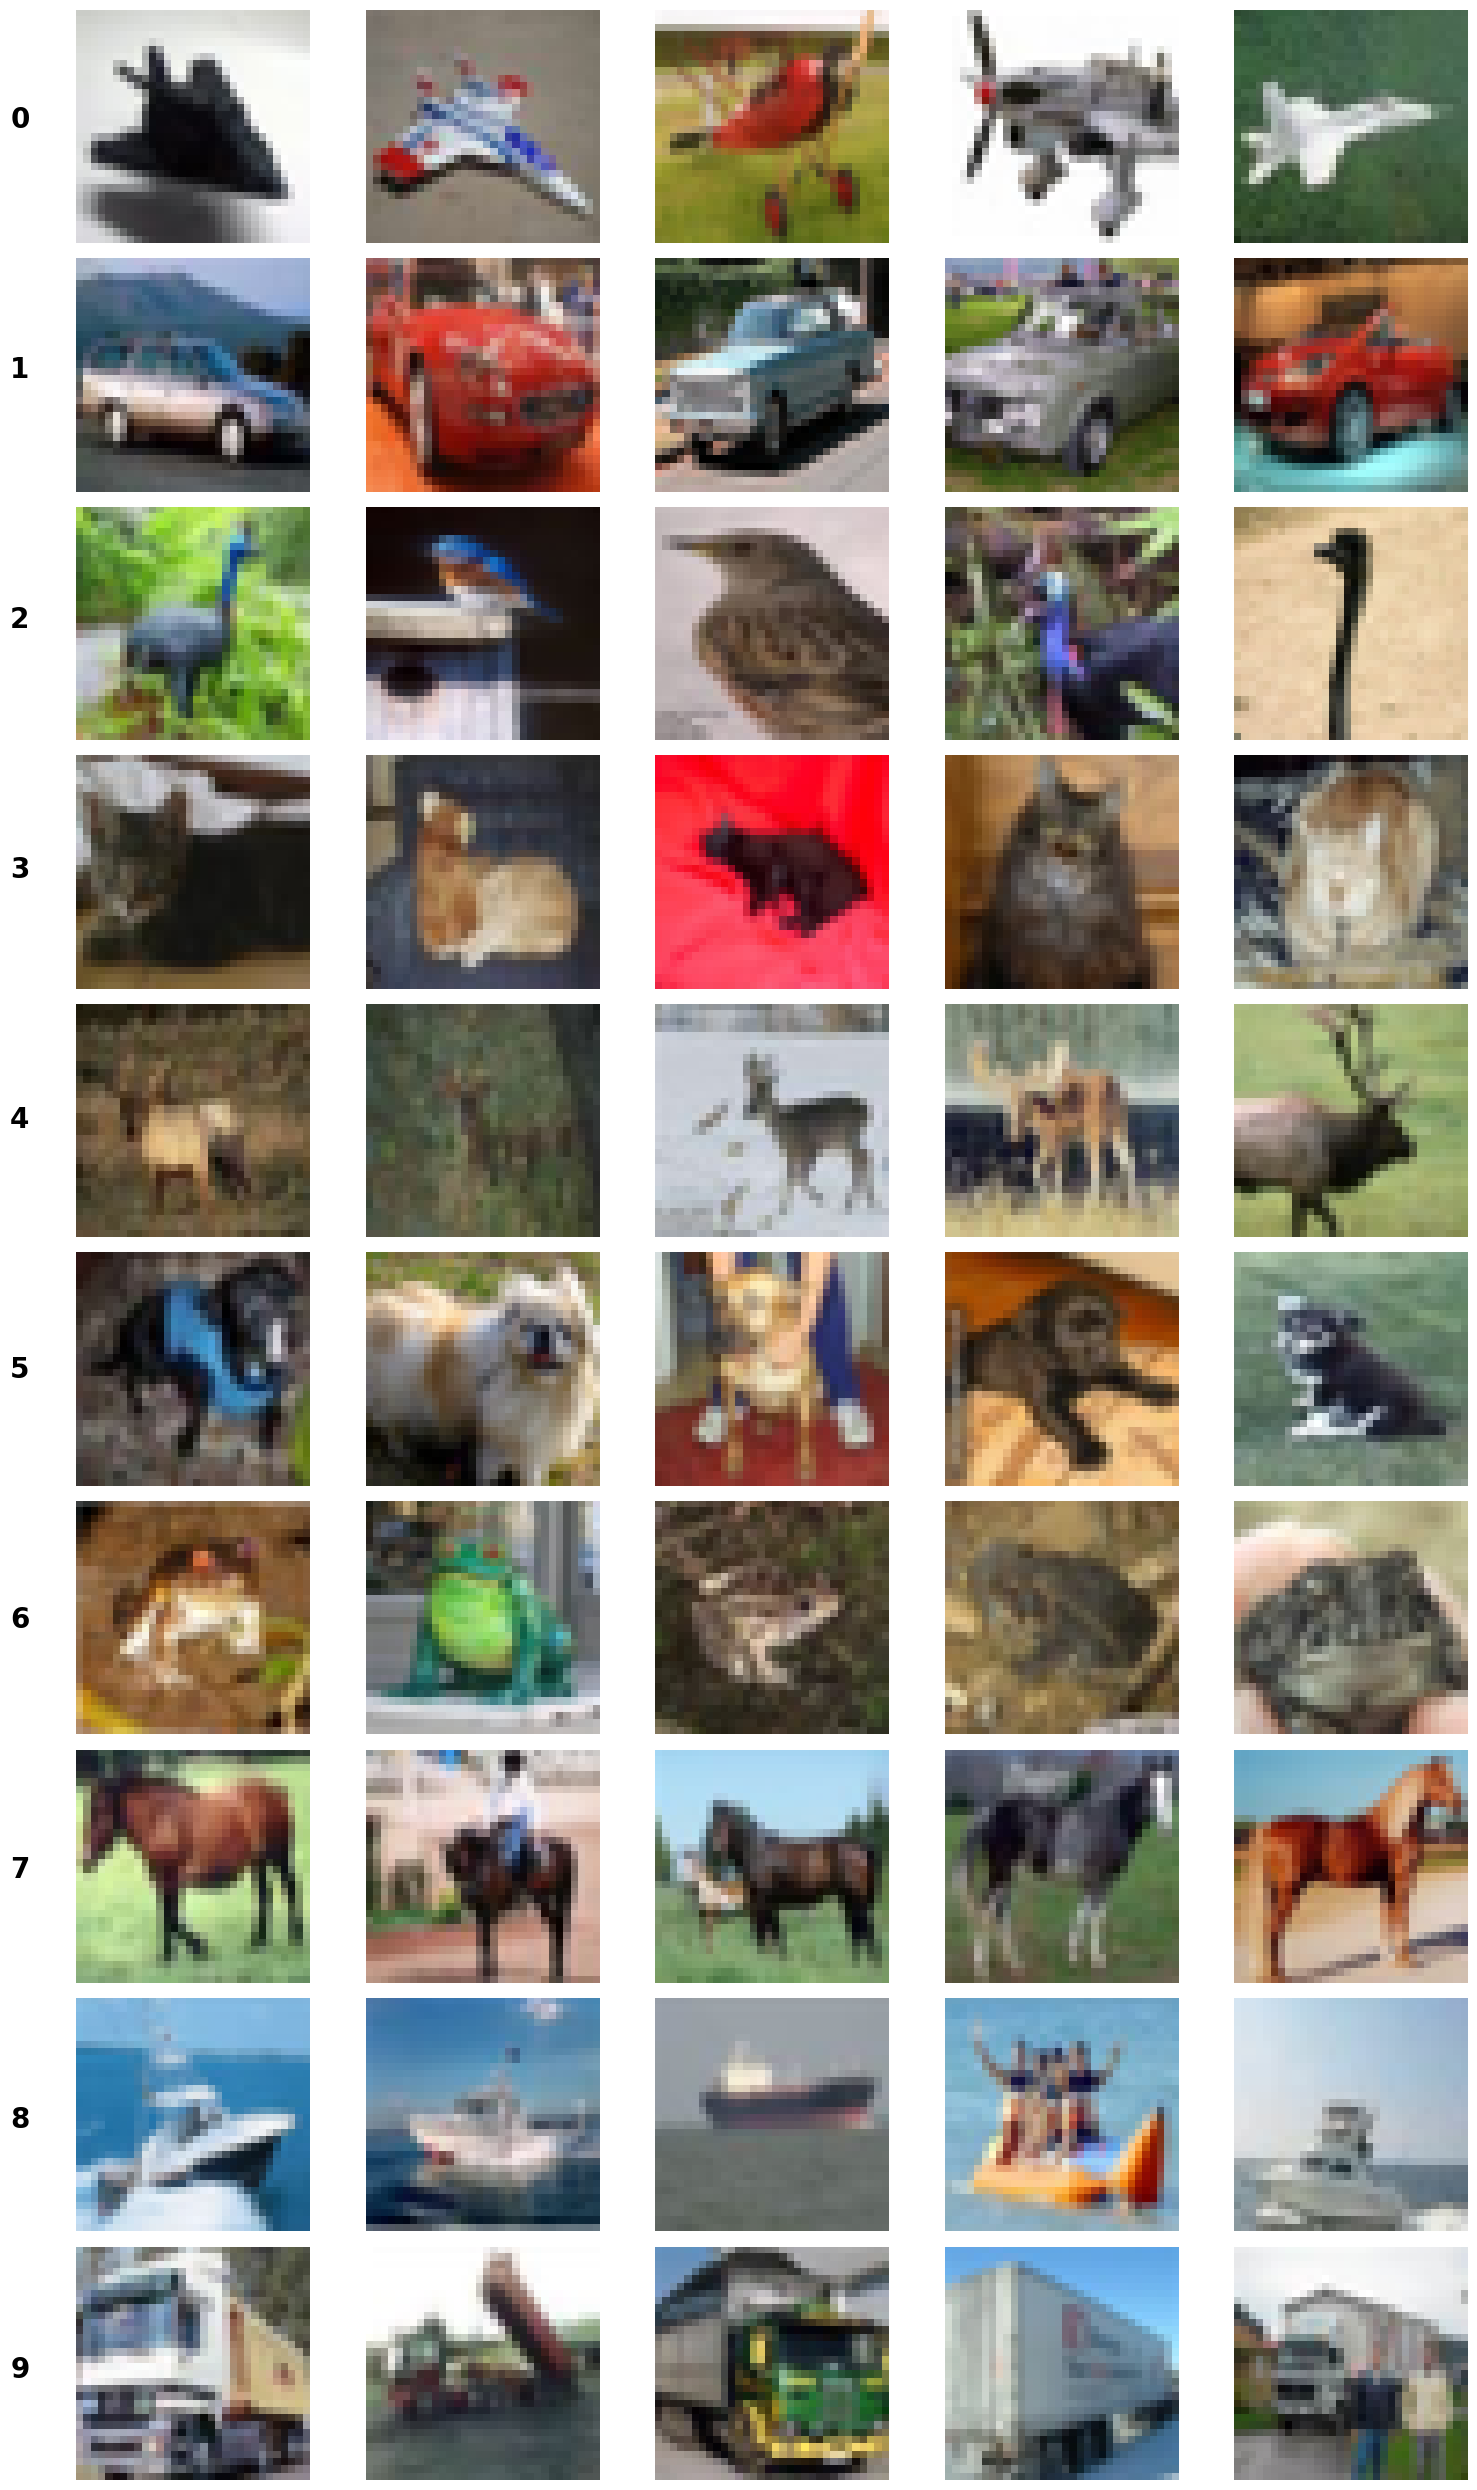

In [7]:
#Display 5 pictures per class
sampels_per_class = 5
fig, ax = plt.subplots(count_labels, sampels_per_class, figsize=(15, 25))

for label, row in enumerate(ax):
    images = train_images[train_labels.flatten() == label][:sampels_per_class]

    for i, img in enumerate(images):
        row[i].imshow(img)
        row[i].axis("off")
    fig.text(0.005, (1 - (label + 0.5) / count_labels), label,
             fontsize=20, fontweight="bold", ha="right", va="center")
plt.tight_layout()
plt.show()

In [8]:
# # Define the label names for the CIFAR-10 dataset
# label_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
#                'dog', 'frog', 'horse', 'ship', 'truck']

# # Print label names
# print(label_names)


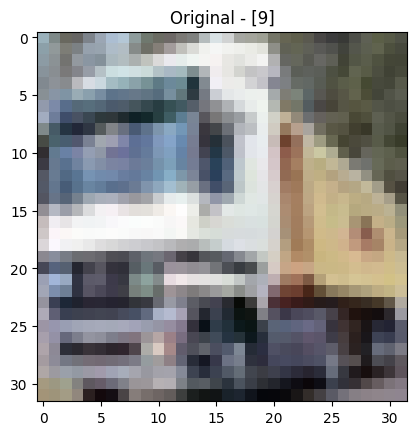

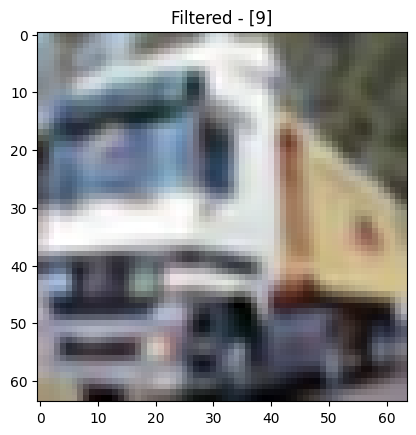

In [9]:
# Display the initial image
plt.imshow(train_images[1])
plt.title(f"Original - {train_labels[1]}")
plt.axis
plt.show()

# Display the filtered image, upscaled  bilinear interpolation (INTER_LINEAR), which can make images blurry
train_images_resized = np.array(cv2.resize(train_images[1], (64, 64), interpolation=cv2.INTER_CUBIC))
plt.imshow(train_images_resized)
plt.title(f"Filtered - {train_labels[1]}")
plt.axis
plt.show()

In [10]:
def preprocess_image(image):

    # Apply Sharpening Filter to enhance clarity
    #kernel = np.array([[0, -1, 0],
                       #[-1, 5, -1],
                       #[0, -1, 0]])
    #image = cv2.filter2D(image, -1, kernel)

    # Resize with high-quality biliniar interpolation
    image = cv2.resize(image, (64, 64), interpolation=cv2.INTER_LINEAR)

    return image

# Apply preprocessing to all images
train_images_filtered = np.array([preprocess_image(img) for img in train_images])
test_images_filtered = np.array([preprocess_image(img) for img in test_images])

# Print final shapes
print(f"Train images shape: {train_images_filtered.shape}")
print(f"Test images shape: {test_images_filtered.shape}")

Train images shape: (50000, 64, 64, 3)
Test images shape: (10000, 64, 64, 3)


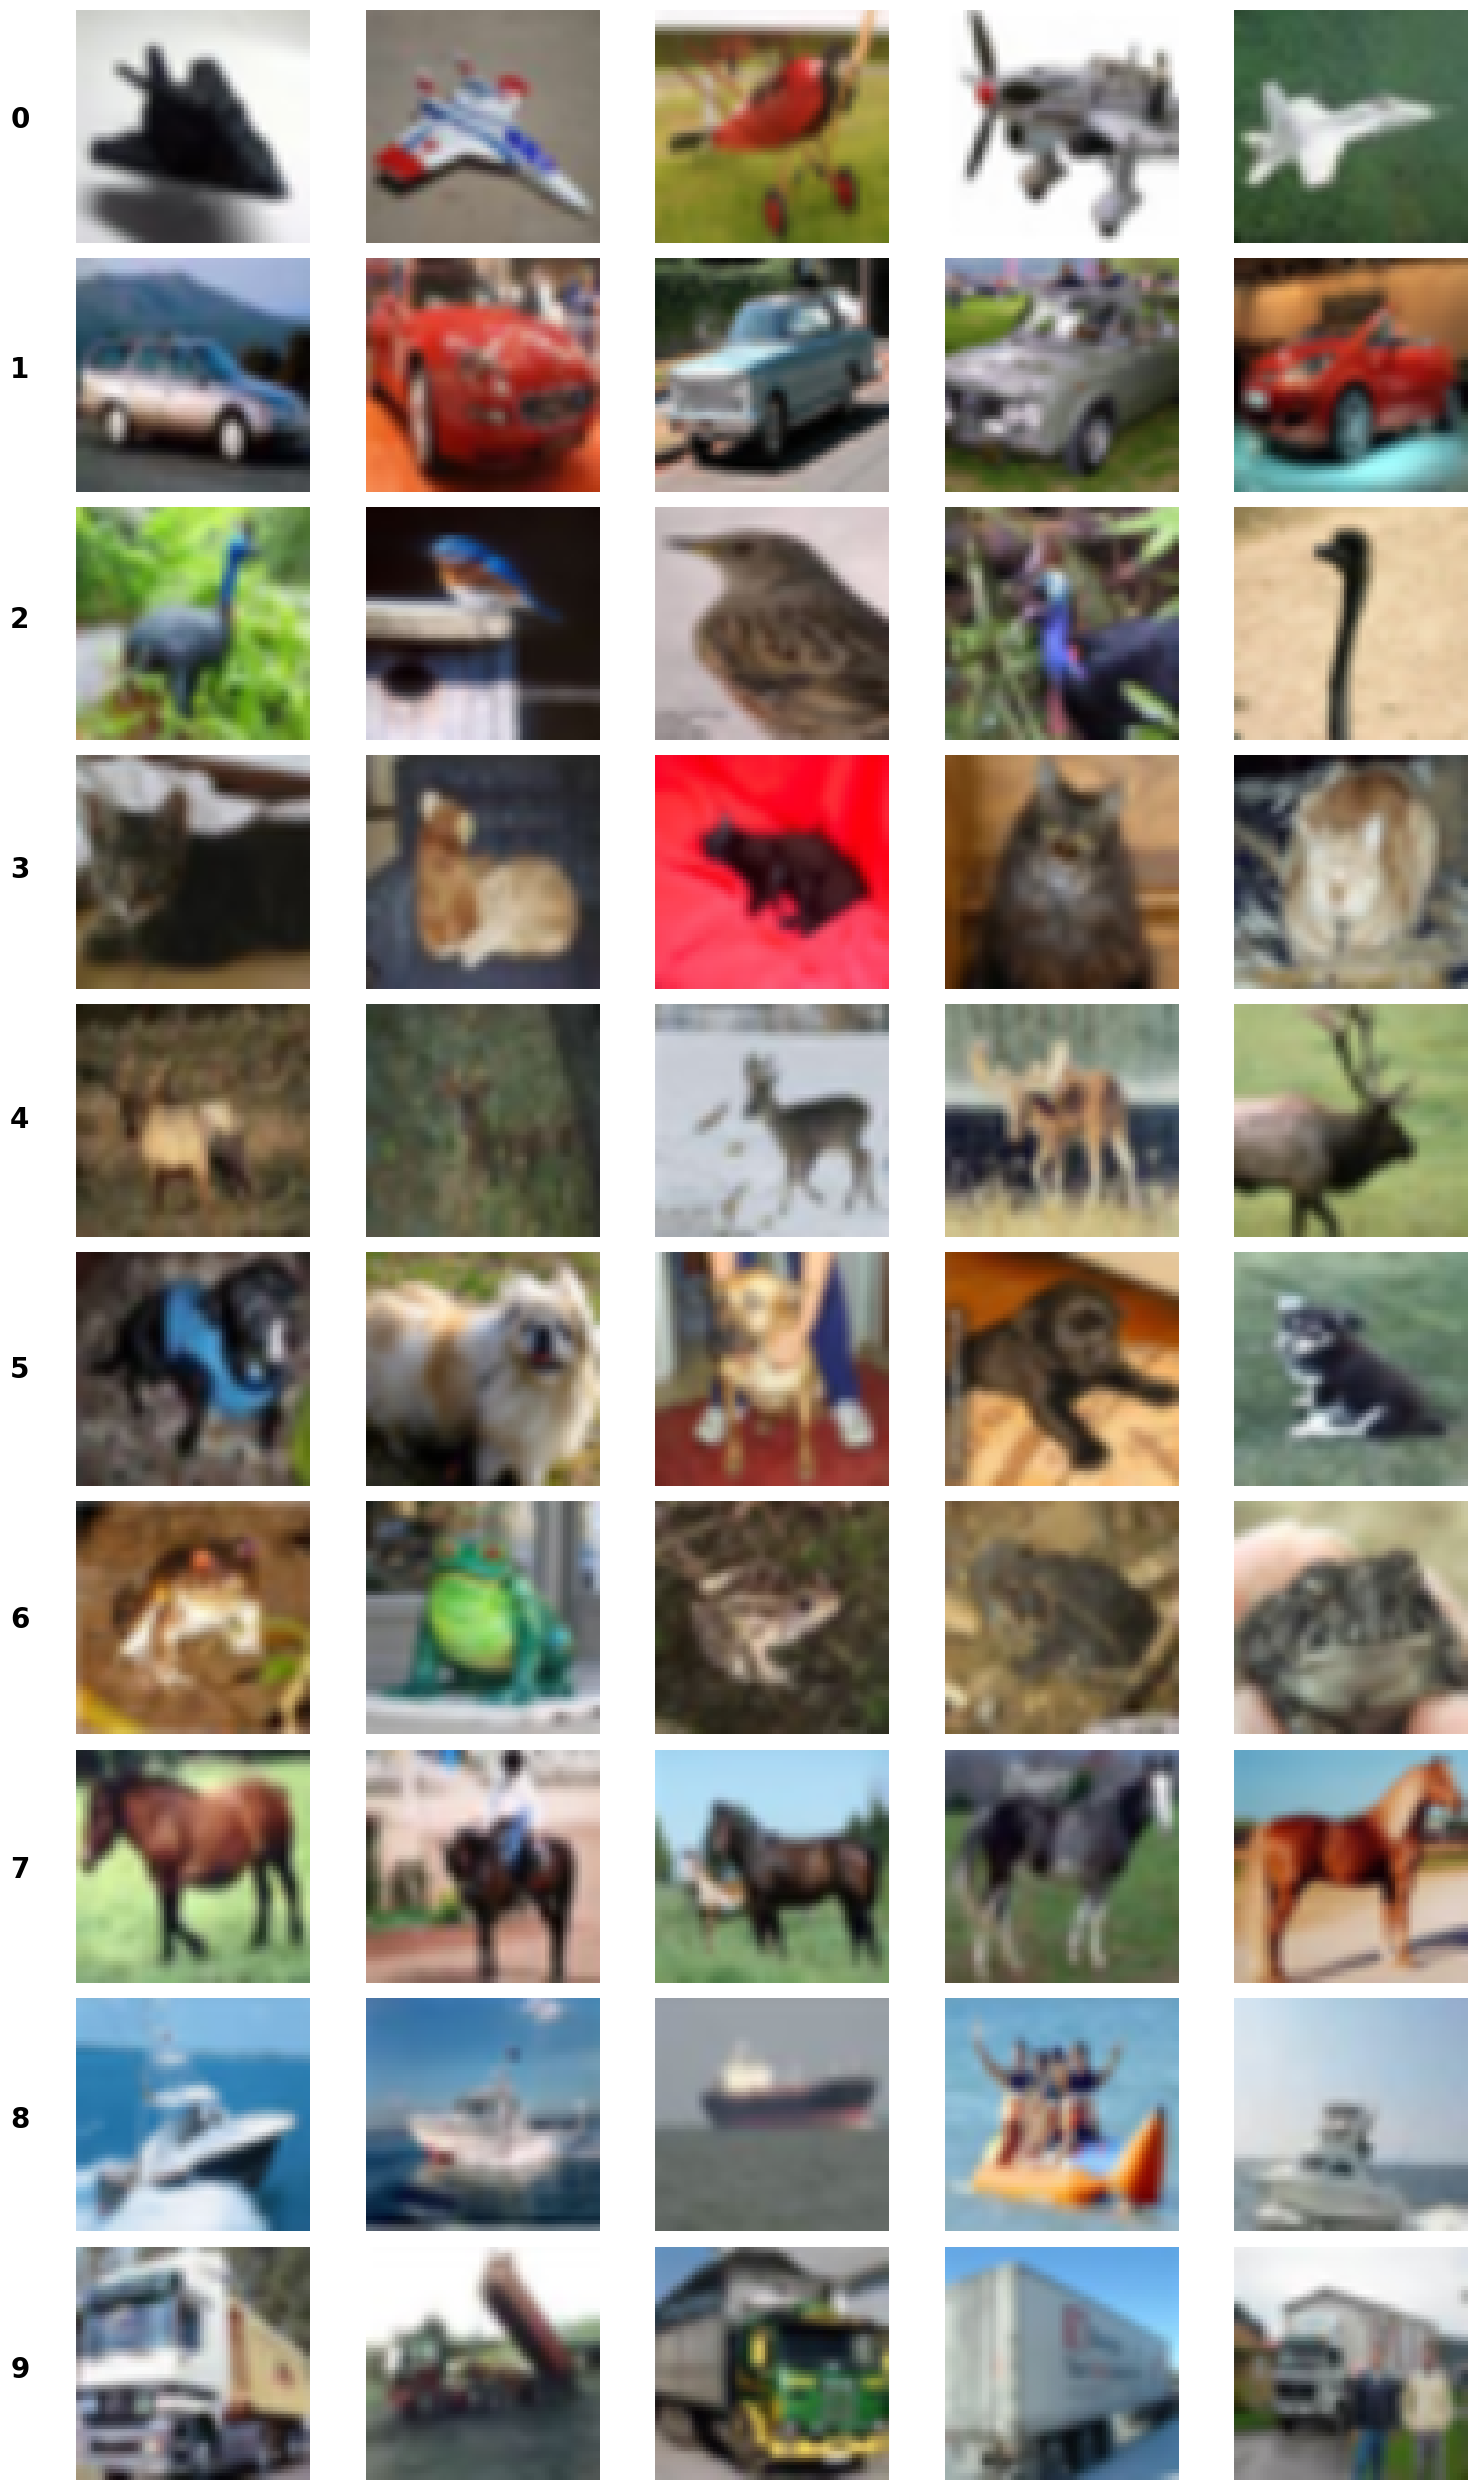

In [11]:
#Display 5 pictures per class
sampels_per_class = 5
fig, ax = plt.subplots(count_labels, sampels_per_class, figsize=(15, 25))

for label, row in enumerate(ax):
    images = train_images_filtered[train_labels.flatten() == label][:sampels_per_class]

    for i, img in enumerate(images):
        row[i].imshow(img)
        row[i].axis("off")
    fig.text(0.005, (1 - (label + 0.5) / count_labels), label,
             fontsize=20, fontweight="bold", ha="right", va="center")
plt.tight_layout()
plt.show()

In [12]:
# # Normalize pixel values to [0,1] range.
# train_images_norm = train_images/255
# test_images_norm = test_images/255

# print(f'Train_size:{train_images.shape}')
# print(f'Test_size:{test_images.shape}')

In the documentation  for ResNet50Note here https://keras.io/api/applications/resnet/ we see: "each Keras Application expects a specific kind of input preprocessing. For ResNet, call keras.applications.resnet.preprocess_input on your inputs before passing them to the model. resnet.preprocess_input will convert the input images from RGB to BGR, then will zero-center each color channel with respect to the ImageNet dataset, without scaling."


To properly preprocess our images for ResNet50 in Keras, we follow these steps:

1. Understanding ResNet Preprocessing
The ResNet50 model in Keras expects:

RGB to BGR conversion (since it was trained on ImageNet with OpenCV's BGR format).

Zero-centering each channel using ImageNet's mean pixel values.

No additional scaling (e.g., no division by 255).

2. Apply Preprocessing Using keras.applications.resnet.preprocess_input

In [13]:
from keras.applications.resnet import preprocess_input

# Convert images to float32 and preprocess
train_images_preprocessed = preprocess_input(train_images_filtered)

# Ensure both train and test images are preprocessed
test_images_preprocessed = preprocess_input(test_images_filtered)



In [14]:
train_images_preprocessed = train_images_preprocessed.astype(np.float32)
test_images_preprocessed = test_images_preprocessed.astype(np.float32)


# **4. Load Pretrained ResNet50 Model**

In [15]:
# Load the RseNet50 model
base_model = ResNet50(

    include_top=False,
    weights="imagenet",
    input_shape=(64, 64, 3),
    classifier_activation="softmax",
    name="resnet50"
)
# Freeze the base model to retain its pre-trained weights
base_model.trainable = False

# **5. Build and Customize the Model Head**

In [16]:
# Create a custom top layer+regularizers
from tensorflow.keras import layers, models, regularizers

# Create a custom top layer with L2 regularization
model = models.Sequential([
    base_model,
    # Converts the feature maps into a single vector
    layers.GlobalAveragePooling2D(),
    # Add a fully connected layer with 256 neurons and L2 regularization
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    # Add a fully connected layer with 128 neurons and L2 regularization
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01)), layers.BatchNormalization(),
    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01)), layers.BatchNormalization(),
    # Drop 60% neurons to prevent overfitting
    layers.Dropout(0.6),
    # Final layer with 10 outputs for 10 classes
    layers.Dense(10, activation='softmax')
])

# **6. Compile the Model**

In [17]:
#compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# If using categorical_crossentropy →  Convert labels to one-hot encoding (to_categorical()).
#If using sparse_categorical_crossentropy →  Use raw integer labels (0-9), no need for to_categorical().
# Show model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 2, 2, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,154,826 (92.14 MB)

 Trainable params: 566,730 (2.16 MB)

 Non-trainable params: 23,588,096 (89.98 MB)

# **7. Train the Custom Model Head**

In [18]:
# Disabled remote MLflow URI for Colab compatibility
import os
import mlflow

# Install MLflow
os.environ["MLFLOW_TRACKING_TOKEN"] = "2trhu2tRjtscY6dP9WMidT9PtzR_5mWegN9gyEDPNjVLtAqQ6"

# MLflow server URI
# mlflow.set_tracking_uri("http://127.0.0.1:5000")

# Experement name
mlflow.set_experiment("Cifar10_Experiment")

<Experiment: artifact_location='file:///kaggle/working/mlruns/779844726742231377', creation_time=1743814234923, experiment_id='779844726742231377', last_update_time=1743814234923, lifecycle_stage='active', name='Cifar10_Experiment', tags={}>

In [19]:
#end current run
#mlflow.end_run()

In [ ]:
# ⚠️ Disabled remote MLflow URI for Colab compatibility
import mlflow
import mlflow.tensorflow
import numpy as np
import os

# Set MLflow to log metrics to the tracking server
# mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("Cifar10_Experiment")

# Define a local directory for artifacts (to avoid cloud storage)
artifact_local_path = "./mlruns_local"
os.makedirs(artifact_local_path, exist_ok=True)

with mlflow.start_run(run_name="50_Interp_lin_32_n50000_training"):
    mlflow.set_tag("model_name", "resnet50_cifar10")

    # Log hyperparameters (Sent to MLflow Server)
    mlflow.log_param("epochs", 5)
    mlflow.log_param("batch_size", 32)
    mlflow.log_param("optimizer", "Adam")
    mlflow.log_param("learning_rate", 1e-4)

    # Train the model
    history = model.fit(
        train_images_preprocessed, train_labels,
        epochs=5, batch_size=32,
        validation_data=(test_images_preprocessed, test_labels)
    )

    # Log final metrics (Sent to MLflow Server)
    mlflow.log_metric("final_train_accuracy", history.history['accuracy'][-1])
    mlflow.log_metric("final_val_accuracy", history.history['val_accuracy'][-1])
    mlflow.log_metric("final_train_loss", history.history['loss'][-1])
    mlflow.log_metric("final_val_loss", history.history['val_loss'][-1])

    # Log per-epoch metrics (Sent to MLflow Server)
    for epoch in range(len(history.history['accuracy'])):
        mlflow.log_metric("train_accuracy", history.history['accuracy'][epoch], step=epoch)
        mlflow.log_metric("val_accuracy", history.history['val_accuracy'][epoch], step=epoch)
        mlflow.log_metric("train_loss", history.history['loss'][epoch], step=epoch)
        mlflow.log_metric("val_loss", history.history['val_loss'][epoch], step=epoch)

    # Save model locally (Avoid Cloud Storage)
    local_model_path = os.path.join(artifact_local_path, "resnet50_model.keras")
    model.save(local_model_path)

    # ✅ Instead of `mlflow.log_artifact()`, print the local path
    print(f"✅ Model saved locally at: {local_model_path}")
    print("ℹ️ Artifacts are stored locally to avoid cloud authentication issues.")

    print("✅ Training complete! Metrics logged to MLflow server, model saved locally.")

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 22ms/step - accuracy: 0.5909 - loss: 4.9888 - val_accuracy: 0.7217 - val_loss: 1.2637
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.7178 - loss: 1.2488 - val_accuracy: 0.7342 - val_loss: 1.0284
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.7358 - loss: 1.0652 - val_accuracy: 0.7352 - val_loss: 1.0162
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.7482 - loss: 0.9962 - val_accuracy: 0.7471 - val_loss: 0.9649
Epoch 5/5
 382/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.7570 - loss: 0.9783

# **9. Evaluate Model Performance**

In [ ]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(test_images_preprocessed, test_labels)

print(f'Test accuracy: {test_accuracy*100:.2f} %')

# **10. Optimize and Experiment Further**

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.losses import SparseCategoricalCrossentropy
import os
import mlflow
import mlflow.tensorflow

# ==== PHASE 1: Partial Unfreeze (last 70 layers) ====
for layer in base_model.layers[:-70]:
    layer.trainable = False
for layer in base_model.layers[-70:]:
    layer.trainable = True

# Compile model for Phase 1
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

# MLflow setup
mlflow.set_experiment("Cifar10_Experiment")
artifact_local_path = "./mlruns_local_fine_tuned"
os.makedirs(artifact_local_path, exist_ok=True)

with mlflow.start_run(run_name="50_Interp_lin_32_gradual_fine_tuning"):
    mlflow.set_tag("model_name", "resnet50_cifar10_gradual_fine_tuned")

    # Log common hyperparameters
    mlflow.log_param("batch_size", 32)
    mlflow.log_param("optimizer", "Adam")
    mlflow.log_param("train_samples", len(train_images_preprocessed))
    mlflow.log_param("phase_1_epochs", 2)
    mlflow.log_param("phase_1_lr", 1e-4)

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        min_delta=1e-3,
        verbose=1
    )

    # ======= PHASE 1 Training =======
    history_phase1 = model.fit(
        train_images_preprocessed, train_labels,
        epochs=2,
        batch_size=32,
        validation_data=(test_images_preprocessed, test_labels),
        callbacks=[early_stopping]
    )

    # Log Phase 1 metrics
    for epoch, (ta, va, tl, vl) in enumerate(zip(
        history_phase1.history['accuracy'],
        history_phase1.history['val_accuracy'],
        history_phase1.history['loss'],
        history_phase1.history['val_loss']
    )):
        mlflow.log_metric("phase1_train_accuracy", ta, step=epoch)
        mlflow.log_metric("phase1_val_accuracy", va, step=epoch)
        mlflow.log_metric("phase1_train_loss", tl, step=epoch)
        mlflow.log_metric("phase1_val_loss", vl, step=epoch)

    # ======= PHASE 2: Fine-tuning (Unfreeze last 20 non-BN layers) =======
    non_bn_layers = [layer for layer in base_model.layers if not isinstance(layer, tf.keras.layers.BatchNormalization)]

    for layer in base_model.layers:
        if not isinstance(layer, tf.keras.layers.BatchNormalization):
            if layer in non_bn_layers[-10:]:
                layer.trainable = True
            else:
                layer.trainable = False
        else:
            layer.trainable = False  # Always freeze BatchNorm

    # Compile for fine-tuning
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
        loss=SparseCategoricalCrossentropy(from_logits=False),
        metrics=['accuracy']
    )

    mlflow.log_param("phase_2_epochs", 3)
    mlflow.log_param("phase_2_lr", 5e-6)
    mlflow.log_param("batchnorm_frozen", True)

    # Callbacks
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=1,
        min_lr=1e-6,
        verbose=1
    )
    checkpoint_path = os.path.join(artifact_local_path, "best_model_val_acc.keras")
    model_checkpoint = ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=False,
        mode='max',
        verbose=1
    )

    # ======= PHASE 2 Training =======
    history_phase2 = model.fit(
        train_images_preprocessed, train_labels,
        epochs=3,
        batch_size=32,
        validation_data=(test_images_preprocessed, test_labels),
        callbacks=[early_stopping, reduce_lr, model_checkpoint]
    )

    # Log Phase 2 metrics
    phase1_len = len(history_phase1.history['accuracy'])
    for epoch, (ta, va, tl, vl) in enumerate(zip(
        history_phase2.history['accuracy'],
        history_phase2.history['val_accuracy'],
        history_phase2.history['loss'],
        history_phase2.history['val_loss']
    ), start=phase1_len):
        mlflow.log_metric("phase2_train_accuracy", ta, step=epoch)
        mlflow.log_metric("phase2_val_accuracy", va, step=epoch)
        mlflow.log_metric("phase2_train_loss", tl, step=epoch)
        mlflow.log_metric("phase2_val_loss", vl, step=epoch)

    # Final metrics
    mlflow.log_metric("final_train_accuracy", history_phase2.history['accuracy'][-1])
    mlflow.log_metric("final_val_accuracy", history_phase2.history['val_accuracy'][-1])
    mlflow.log_metric("final_train_loss", history_phase2.history['loss'][-1])
    mlflow.log_metric("final_val_loss", history_phase2.history['val_loss'][-1])

    # Save model
    fine_model_path = os.path.join(artifact_local_path, "resnet50_fine_tuned.keras")
    model.save(fine_model_path)

    print(f"✅ Fine-tuned model saved locally at: {fine_model_path}")
    print("ℹ️ Metrics logged to MLflow tracking server. Artifacts stored locally.")

# Final evaluation
test_loss, test_accuracy = model.evaluate(test_images_preprocessed, test_labels)
print(f"📊 Test accuracy: {test_accuracy * 100:.2f} %")


In [ ]:
import matplotlib.pyplot as plt

# === Extract metrics ===

# Initial training
train_loss_init = history.history['loss']
val_loss_init = history.history['val_loss']
train_acc_init = history.history['accuracy']
val_acc_init = history.history['val_accuracy']

# Fine-tuning: Phase 1
train_loss_ft1 = history_phase1.history['loss']
val_loss_ft1 = history_phase1.history['val_loss']
train_acc_ft1 = history_phase1.history['accuracy']
val_acc_ft1 = history_phase1.history['val_accuracy']

# Fine-tuning: Phase 2
train_loss_ft2 = history_phase2.history['loss']
val_loss_ft2 = history_phase2.history['val_loss']
train_acc_ft2 = history_phase2.history['accuracy']
val_acc_ft2 = history_phase2.history['val_accuracy']

# === Plot ===
fig, ax = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("V_18_0_ResNet50_Regul_L2=0.001_d0.6_2StepUnfreeze_BNfrozen_N50000_TrainLR1e-4_FT_LR5e-6_EarlyStop5_ReduceLR_Batch32_Epochs10",fontsize=14)
# --- Loss: Initial Training ---
ax[0, 0].plot(train_loss_init, label='Train Loss', color='blue')
ax[0, 0].plot(val_loss_init, label='Val Loss', color='red')
ax[0, 0].set_title('Initial Training: Loss')
ax[0, 0].set_xlabel('Epoch')
ax[0, 0].set_ylabel('Loss')
ax[0, 0].legend()
ax[0, 0].grid(True)

# --- Accuracy: Initial Training ---
ax[0, 1].plot(train_acc_init, label='Train Accuracy', color='blue')
ax[0, 1].plot(val_acc_init, label='Val Accuracy', color='red')
ax[0, 1].set_title('Initial Training: Accuracy')
ax[0, 1].set_xlabel('Epoch')
ax[0, 1].set_ylabel('Accuracy')
ax[0, 1].legend()
ax[0, 1].grid(True)

# --- Loss: Fine-Tuning (Phases 1 & 2) ---
combined_loss_train = train_loss_ft1 + train_loss_ft2
combined_loss_val = val_loss_ft1 + val_loss_ft2
epochs_ft = list(range(1, len(combined_loss_train) + 1))

ax[1, 0].plot(epochs_ft, combined_loss_train, label='Train Loss (FT)', color='blue')
ax[1, 0].plot(epochs_ft, combined_loss_val, label='Val Loss (FT)', color='red')
ax[1, 0].axvline(x=len(train_loss_ft1), color='gray', linestyle='--', label='Phase 2 Start')
ax[1, 0].set_title('Fine-Tuning: Loss')
ax[1, 0].set_xlabel('Epoch')
ax[1, 0].set_ylabel('Loss')
ax[1, 0].legend()
ax[1, 0].grid(True)

# --- Accuracy: Fine-Tuning (Phases 1 & 2) ---
combined_acc_train = train_acc_ft1 + train_acc_ft2
combined_acc_val = val_acc_ft1 + val_acc_ft2

ax[1, 1].plot(epochs_ft, combined_acc_train, label='Train Accuracy (FT)', color='blue')
ax[1, 1].plot(epochs_ft, combined_acc_val, label='Val Accuracy (FT)', color='red')
ax[1, 1].axvline(x=len(train_acc_ft1), color='gray', linestyle='--', label='Phase 2 Start')
ax[1, 1].set_title('Fine-Tuning: Accuracy')
ax[1, 1].set_xlabel('Epoch')
ax[1, 1].set_ylabel('Accuracy')
ax[1, 1].legend()
ax[1, 1].grid(True)

# Final layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
# building classification report
y_pred = model.predict(test_images_preprocessed,verbose=0)
y_pred = np.argmax(y_pred,axis=1) # Converts the probability distributions into class labels
# [0.1, 0.05, 0.6, 0.25], argmax returns 2 (since 0.6 is the highest probability).
print(classification_report(test_labels, y_pred))

In [ ]:
# Assuming train_labels contains the labels for train_images_preprocessed
cat_label = 3

# Find the index of the first image with label 3 (cat)
cat_index = (train_labels == cat_label).nonzero()[0][0]

# Extract the corresponding image
cat_image = train_images_filtered[cat_index]

# Display the image
plt.imshow(cat_image)  # Remove cmap='gray' if the image is in RGB
plt.title(f"Label: {cat_label} (Cat)")
plt.axis('off')
plt.show()

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Assuming train_images_preprocessed and train_labels are your data
m, n = train_images_filtered.shape[0], train_images_filtered.shape[1:]

fig, axes = plt.subplots(8, 8, figsize=(10, 10))
fig.tight_layout(pad=0.5, rect=[0, 0.03, 1, 0.95])  # Adjust layout

for i, ax in enumerate(axes.flat):
    # Select random indices
    random_index = np.random.randint(m)

    # Select the image and reshape it
    X_random_reshaped = train_images_filtered[random_index]

    # Display the image
    ax.imshow(X_random_reshaped, cmap=None)  # Remove cmap for RGB images

    # Predict using the Neural Network
    prediction = model.predict(X_random_reshaped.reshape(1, *n))
    prediction_p = tf.nn.softmax(prediction)
    yhat = np.argmax(prediction_p)

    # Display the label above the image
    ax.set_title(f"{train_labels[random_index]},{yhat}", fontsize=8)
    ax.set_axis_off()

fig.suptitle("True Label, Predicted Label", fontsize=16)
plt.show()

In [ ]:
def display_errors(model, X, y):
    """
    Calculate the number of misclassified images.

    Parameters:
    - model: Trained model to make predictions.
    - X: Input data (images).
    - y: True labels.

    Returns:
    - Number of misclassified images.
    """
    # Predict the probabilities for each class
    predictions = model.predict(X)

    # Get the predicted class labels
    predicted_labels = np.argmax(predictions, axis=1)

    # Ensure true labels are in 1D format
    true_labels = y.flatten()

    # Count the number of misclassified images
    errors = np.sum(predicted_labels != true_labels)

    return errors

In [ ]:
# Displaying 91% of 10000 images to see if they are correctly classified

errors = display_errors(model, test_images_preprocessed, test_labels)
print(f"{errors} errors out of {len(test_images_preprocessed)} images")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Function to display only misclassified images from a random subset of 100 images
def display_misclassified_images(model, images, labels, subset_size=100):
    # Select a random subset of 100 images
    indices = np.random.choice(len(images), subset_size, replace=False)
    selected_images = images[indices]
    selected_labels = labels[indices]

    # Predict the labels for the selected images
    predictions = model.predict(selected_images)
    predicted_labels = np.argmax(predictions, axis=1)

    # Find the misclassified images
    misclassified_indices = np.where(predicted_labels != selected_labels.flatten())[0]
    misclassified_images = selected_images[misclassified_indices]
    misclassified_true_labels = selected_labels[misclassified_indices]
    misclassified_predicted_labels = predicted_labels[misclassified_indices]

    # Plot the misclassified images
    num_errors = len(misclassified_images)
    if num_errors == 0:
        print("No misclassified images in the selected subset.")
        return

    fig, axes = plt.subplots(1, min(num_errors, 10), figsize=(15, 5))  # Display up to 10 errors
    fig.tight_layout(pad=1.0)

    for i, ax in enumerate(axes.flat[:num_errors]):
        # Display the image
        ax.imshow(misclassified_images[i])
        ax.axis('off')

        # Display the true and predicted labels
        true_label = misclassified_true_labels[i]
        predicted_label = misclassified_predicted_labels[i]
        ax.set_title(f"T: {true_label}, P: {predicted_label}", fontsize=8)

    plt.show()

# Display misclassified images from a random subset of 100
display_misclassified_images(model, test_images_filtered, test_labels, subset_size=100)

In [ ]:
import seaborn as sns
# Convert test_labels to a list of unique labels
unique_labels = list(np.unique(test_labels))

# Compute the confusion matrix
cm = confusion_matrix(test_labels, y_pred, labels=unique_labels)

# Plot the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=unique_labels, yticklabels=unique_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Multiclass Confusion Matrix')
plt.show()

#Step 1: Identify Misclassified Images on the Training Set

In [ ]:
def get_misclassified_samples(model, images, labels, subset_size=1000):
    indices = np.random.choice(len(images), subset_size, replace=False)
    selected_images = images[indices]
    selected_labels = labels[indices]

    predictions = model.predict(selected_images)
    predicted_labels = np.argmax(predictions, axis=1)

    misclassified_mask = predicted_labels != selected_labels.flatten()

    return selected_images[misclassified_mask], selected_labels[misclassified_mask]


#Step 2: Apply Data Augmentation to Only Misclassified Images

In [ ]:
# Define augmentation pipeline
augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

# Apply augmentations to misclassified images
def augment_misclassified_images(images, labels, augmentations_per_image=3):
    augmented_images = []
    augmented_labels = []

    for i in range(len(images)):
        for _ in range(augmentations_per_image):
            aug_img = augmentation(tf.expand_dims(images[i], axis=0))  # Add batch dim
            augmented_images.append(aug_img[0].numpy())
            augmented_labels.append(labels[i])

    return np.array(augmented_images), np.array(augmented_labels)


# Step 3: Combine with Original Training Set

In [ ]:
# Step 1: Get misclassified samples from training data
misclassified_imgs, misclassified_labels = get_misclassified_samples(model, train_images_filtered, train_labels, subset_size=5000)

# Step 2: Augment them
aug_imgs, aug_labels = augment_misclassified_images(misclassified_imgs, misclassified_labels, augmentations_per_image=3)

# Step 3: Combine with original training data
train_images_augmented = np.concatenate([train_images_filtered, aug_imgs], axis=0)
train_labels_augmented = np.concatenate([train_labels, aug_labels], axis=0)


#Final Step: Retrain the Model

In [ ]:
from sklearn.utils import shuffle
train_images_augmented, train_labels_augmented = shuffle(train_images_augmented, train_labels_augmented, random_state=42)

In [ ]:
# Convert images to float32 and preprocess
train_images_preprocessed = preprocess_input(train_images_augmented)
train_images_preprocessed = train_images_preprocessed.astype(np.float32)

In [ ]:
print("Train images:", train_images_preprocessed.shape)
print("Train labels:", train_labels_augmented.shape)


In [ ]:
# Set MLflow to log metrics to the tracking server
# mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("Cifar10_Experiment")

# Define a local directory for artifacts (to avoid cloud storage)
artifact_local_path = "./mlruns_local"
os.makedirs(artifact_local_path, exist_ok=True)

with mlflow.start_run(run_name="50_Interp_lin_32_n50000_training"):
    mlflow.set_tag("model_name", "resnet50_cifar10")

    # Log hyperparameters (Sent to MLflow Server)
    mlflow.log_param("epochs", 5)
    mlflow.log_param("batch_size", 32)
    mlflow.log_param("optimizer", "Adam")
    mlflow.log_param("learning_rate", 1e-5)

    # Train the model
    history = model.fit(
        train_images_preprocessed, train_labels_augmented,
        epochs=5, batch_size=32,
        validation_data=(test_images_preprocessed, test_labels)
    )

    # Log final metrics (Sent to MLflow Server)
    mlflow.log_metric("final_train_accuracy", history.history['accuracy'][-1])
    mlflow.log_metric("final_val_accuracy", history.history['val_accuracy'][-1])
    mlflow.log_metric("final_train_loss", history.history['loss'][-1])
    mlflow.log_metric("final_val_loss", history.history['val_loss'][-1])

    # Log per-epoch metrics (Sent to MLflow Server)
    for epoch in range(len(history.history['accuracy'])):
        mlflow.log_metric("train_accuracy", history.history['accuracy'][epoch], step=epoch)
        mlflow.log_metric("val_accuracy", history.history['val_accuracy'][epoch], step=epoch)
        mlflow.log_metric("train_loss", history.history['loss'][epoch], step=epoch)
        mlflow.log_metric("val_loss", history.history['val_loss'][epoch], step=epoch)

    # Save model locally (Avoid Cloud Storage)
    local_model_path = os.path.join(artifact_local_path, "resnet50_model.keras")
    model.save(local_model_path)

    # ✅ Instead of `mlflow.log_artifact()`, print the local path
    print(f"✅ Model saved locally at: {local_model_path}")
    print("ℹ️ Artifacts are stored locally to avoid cloud authentication issues.")

    print("✅ Training complete! Metrics logged to MLflow server, model saved locally.")

In [ ]:
test_loss, test_acc = model.evaluate(test_images_preprocessed, test_labels)
print(f"📊 Test Accuracy After Targeted Augmentation: {test_acc * 100:.2f}%")


In [ ]:
#plotting loss and accuracy

def plot_training_history(history):
    # Accuracy
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Call the function with your model's history
plot_training_history(history)


In [ ]:
# building classification report
y_pred = model.predict(test_images_preprocessed,verbose=0)
y_pred = np.argmax(y_pred,axis=1) # Converts the probability distributions into class labels
# [0.1, 0.05, 0.6, 0.25], argmax returns 2 (since 0.6 is the highest probability).
print(classification_report(test_labels, y_pred))

In [ ]:
# Convert test_labels to a list of unique labels
unique_labels = list(np.unique(test_labels))

# Compute the confusion matrix
cm = confusion_matrix(test_labels, y_pred, labels=unique_labels)

# Plot the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=unique_labels, yticklabels=unique_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Multiclass Confusion Matrix')
plt.show()



### 📌 Final Summary



In [ ]:
# Load the fine-tuned model
from keras.models import load_model
model = load_model("./mlruns_local_fine_tuned/resnet50_fine_tuned.keras")
# Or model = load_model("./mlruns_local_fine_tuned/best_model_val_acc.keras")
# Or model = load_model("./mlruns_local/resnet50_model.keras")
